Lex Albrandt  
CS445  
HW 2  

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy.polynomial.polynomial as poly
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

## Question 1 
  
## 1a)  
  

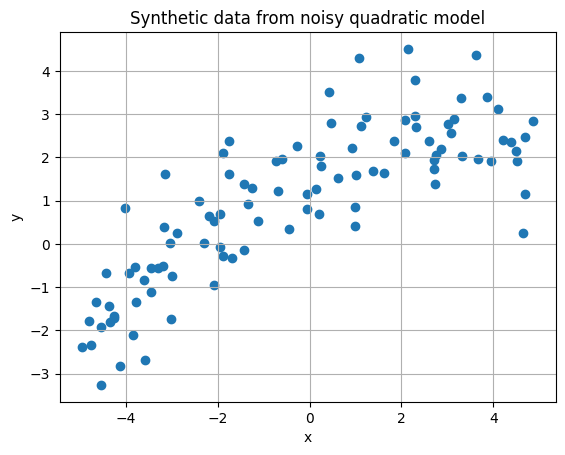

In [2]:
# variable for storing CV MSE values for output later
cv_mse_results = []

# set up for reproducibility
np.random.seed(42)

# 100 samples
n = 100
x_train = np.random.uniform(-5, 5, n)

# for polynomial y = 2 + 0.5x - 0.1x^2
beta = np.array([2, 0.5, -.1])

# Add Gaussian noise
epsilon = np.random.normal(0, 1, n)

# define polynomial
# Expects coefficients from lowest order to highest order
y_true_train = poly.polyval(x_train, beta)
y_train = y_true_train + epsilon

# Plot the data
plt.title("Synthetic data from noisy quadratic model")
plt.scatter(x_train, y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

## 1b) and 1c) and 1d)
  
### Linear Model  
  

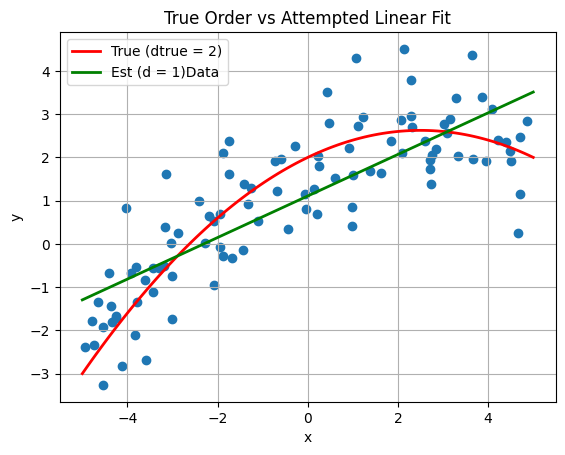

In [3]:
d = 1
beta_hat = poly.polyfit(x_train, y_train, d)

x_true = np.linspace(-5, 5, 100)
y_true = poly.polyval(x_true, beta)
y_true_hat = poly.polyval(x_true, beta_hat)
plt.plot(x_true, y_true, 'r', linewidth = 2)
plt.plot(x_true, y_true_hat, 'g', linewidth = 2)

# Plot scatter plot of generated data
plt.title("True Order vs Attempted Linear Fit")
plt.scatter(x_train, y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend(['True (dtrue = 2)', 'Est (d = 1)' 'Data'], loc = 'upper left')
plt.show()



We see that a regression model with a degree of 1 does not fit this data  
  
Now we will compute training MSE for $d=1$  
  

In [4]:
y_hat_train = poly.polyval(x_train, beta_hat)
mse = np.mean((y_train - y_hat_train) ** 2)
print(f"Training MSE: {mse:.4f}")

Training MSE: 1.0977


We can see that with $d=1$ the MSE is greater than 1, indicating that a linear  
model is a poor fit for our data.  
  
Next we will compute a 5-fold cross-validation for unseen data  
  

In [5]:
# Number of folds
K = 5
d = 1

# Shuffle indices (100 data points)
indices = np.random.permutation(n)
folds = np.array_split(indices, K)

mse_folds = []

for k in range(K):

    # Validation indices
    val_index = folds[k]

    # Training indices
    # Takes all indices up to k, and all indices after k and stacks them
    # into a 1D array
    train_index = np.hstack(folds[:k] + folds[k + 1:])

    # Split data
    x_tr = x_train[train_index]
    y_tr = y_train[train_index]
    x_val = x_train[val_index]
    y_val = y_train[val_index]

    # Fit the model on the training fold
    beta_hat = poly.polyfit(x_tr, y_tr, d)

    # Predict on validation fold
    y_val_hat = poly.polyval(x_val, beta_hat)

    # Compute MSE for this fold
    mse = np.mean((y_val - y_val_hat) ** 2)
    mse_folds.append(mse)

# Cross-Validated MSE
cv_mse = np.mean(mse_folds)
cv_mse_results.append((d, cv_mse))
print(f"5-fold CV MSE for d = 1: {cv_mse:.4f}")
    


5-fold CV MSE for d = 1: 1.1315


### Quadratic Model  
  

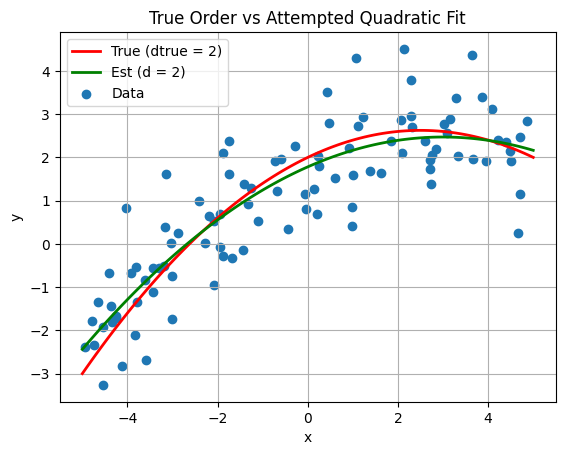

In [6]:
d = 2
beta_hat = poly.polyfit(x_train, y_train, d)

x_true = np.linspace(-5, 5, 100)
y_true = poly.polyval(x_true, beta)
y_true_hat = poly.polyval(x_true, beta_hat)
plt.plot(x_true, y_true, 'r', linewidth = 2)
plt.plot(x_true, y_true_hat, 'g', linewidth = 2)

# Plot scatter plot of generated data
plt.title("True Order vs Attempted Quadratic Fit")
plt.scatter(x_train, y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend(['True (dtrue = 2)', 'Est (d = 2)', 'Data'], loc = 'upper left')
plt.show()

It appears here that a quadratic model is a good fit. We will attempt a cubic  
model to ensure that quadratic is, in fact, the proper fit.  
  
Now we will compute training MSE for $d=2$  
   

In [7]:
y_hat_train = poly.polyval(x_train, beta_hat)
mse = np.mean((y_train - y_hat_train) ** 2)
print(f"Training MSE: {mse:.4f}")

Training MSE: 0.7772


The training MSE here is pretty good, indicating this model order is likely a  
good fit.  
  
Next we will calculate the 5-fold Cross-Validation MSE for unseen data  
 

In [8]:
K = 5
d = 2

indices = np.random.permutation(n)
folds = np.array_split(indices, K)

mse_folds = []

for k in range(K):
    val_index = folds[k]

    train_index = np.hstack(folds[:k] + folds[k + 1:])

    x_tr = x_train[train_index]
    y_tr = y_train[train_index]
    x_val = x_train[val_index]
    y_val = y_train[val_index]

    beta_hat = poly.polyfit(x_tr, y_tr, d)

    y_val_hat = poly.polyval(x_val, beta_hat)
    
    mse = np.mean((y_val - y_val_hat) ** 2) 
    mse_folds.append(mse)

cv_mse = np.mean(mse_folds)
cv_mse_results.append((d, cv_mse))
print(f"5-fold CV MSE for d = 2: {cv_mse:.4f}")

5-fold CV MSE for d = 2: 0.8372


### Cubic Model  
  

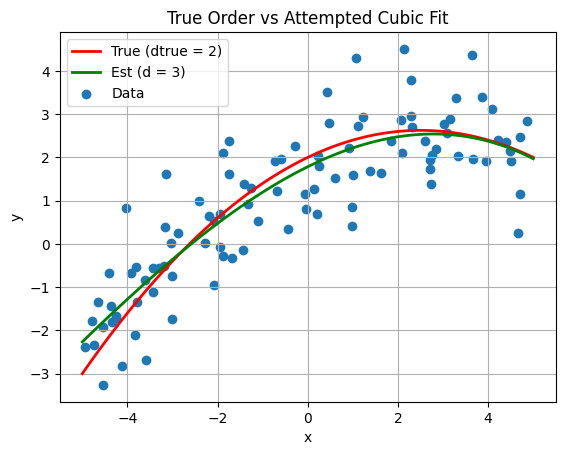

In [9]:
d = 3
beta_hat = poly.polyfit(x_train, y_train, d)

x_true = np.linspace(-5, 5, 100)
y_true = poly.polyval(x_true, beta)
y_true_hat = poly.polyval(x_true, beta_hat)
plt.plot(x_true, y_true, 'r', linewidth = 2)
plt.plot(x_true, y_true_hat, 'g', linewidth = 2)

# Plot scatter plot of generated data
plt.title("True Order vs Attempted Cubic Fit")
plt.scatter(x_train, y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend(['True (dtrue = 2)', 'Est (d = 3)', 'Data'], loc = 'upper left')
plt.show()

It is difficult to tell from this graph if cubic is a better fit, which points out  
a flaw of trying to "eyeball" the fit: our estimation may not be mathematically sound  
 
Let's compute the training MSE for $d=3$  
  

In [10]:
y_hat_train = poly.polyval(x_train, beta_hat)
mse = np.mean((y_train - y_hat_train) ** 2)
print(f"Training MSE: {mse:.4f}")

Training MSE: 0.7725


We can see that the MSE is slightly farther away from 1 than for $d=2$, but appears  
to be a decent fit. We will now compute the CV MSE for this model order.  
 

In [11]:
K = 5
d = 3

mse_folds = []

for k in range(K):
    
    val_index = folds[k]

    train_index = np.hstack(folds[:k] + folds[k + 1:])

    x_tr = x_train[train_index]
    y_tr = y_train[train_index]
    x_val = x_train[val_index]
    y_val = y_train[val_index]

    beta_hat = poly.polyfit(x_tr, y_tr, d)

    y_val_hat = poly.polyval(x_val, beta_hat)

    mse = np.mean((y_val - y_val_hat) ** 2)
    mse_folds.append(mse)

cv_mse = np.mean(mse_folds)
cv_mse_results.append((d, cv_mse))
print(f"5-fold CV MSE for d = 3: {cv_mse:.4f}")

5-fold CV MSE for d = 3: 0.8382


### Model order 10   
  

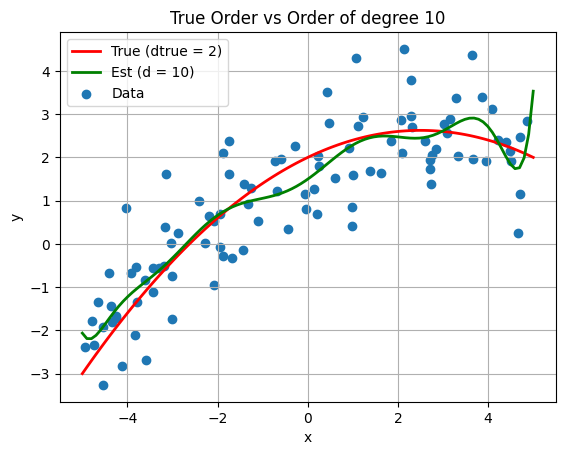

In [12]:
d = 10
beta_hat = poly.polyfit(x_train, y_train, d)

x_true = np.linspace(-5, 5, 100)
y_true = poly.polyval(x_true, beta)
y_true_hat = poly.polyval(x_true, beta_hat)
plt.plot(x_true, y_true, 'r', linewidth = 2)
plt.plot(x_true, y_true_hat, 'g', linewidth = 2)

# Plot scatter plot of generated data
plt.title("True Order vs Order of degree 10")
plt.scatter(x_train, y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend(['True (dtrue = 2)', 'Est (d = 10)', 'Data'], loc = 'upper left')
plt.show()

In this example we see that a model degree of 10 clearly overfits the data and does  
not generalize properly.  
  
Now we will calculate training MSE for $d=10$  
  

In [13]:
y_hat_train = poly.polyval(x_train, beta_hat)
mse = np.mean((y_train - y_hat_train) ** 2)
print(f"Training MSE: {mse:.4f}")

Training MSE: 0.7399


We can see that the training MSE for $d=10$ indicates this model order is beginning to  
overfit the data. Let's calculate the CV MSE for $d=10$  
 

In [14]:
K = 5
d = 10

mse_folds = []

for k in range(K):

    val_index = folds[k]
    train_index = np.hstack(folds[:k] + folds[k + 1:])

    x_tr = x_train[train_index]
    y_tr = y_train[train_index]
    x_val = x_train[val_index]
    y_val = y_train[val_index]

    beta_hat = poly.polyfit(x_tr, y_tr, d)

    y_val_hat = poly.polyval(x_val, beta_hat)

    mse = np.mean((y_val - y_val_hat) ** 2)
    mse_folds.append(mse)

cv_mse = np.mean(mse_folds)
cv_mse_results.append((d, cv_mse))
print(f"5-fold CV MSE for d = 10: {cv_mse:.4f}")

5-fold CV MSE for d = 10: 1.0414


Our results from the 5-fold CV MSE for $d=10$ once again show  
that this model is beginning to overfit the data.  
  
## 1e)  
  
Below we will compare the CV MSE values for each of the models to  
determine which model has the best generalization performance.  

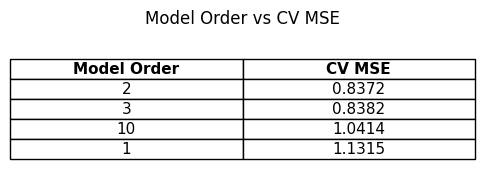

In [15]:
sorted_cvmse = sorted(cv_mse_results, key = lambda x: x[1])
headers = ["Model Order", "CV MSE"]
cell_text = [[d, f"{mse:.4f}"] for d, mse in sorted_cvmse]

fig, ax = plt.subplots(figsize = (5, 2))
ax.axis("off")

table = ax.table(cellText = cell_text, colLabels = headers, loc = 'center', cellLoc = "center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight = "bold")

plt.title("Model Order vs CV MSE")
plt.show()

Based on the above table we can see that the model with order $d=2$  
showed the best generalization  
  
## 1f)  
  
Higher-order models are able to achieve lower training error because  
they can fit the actual signal and any noise in the training data, but  
when they see new data, the error is higher because they have high variance  
and are overfitting the data.  
 
## 1g)  
The value of irreducible error is the vairance of the noise term and cannot  
be reduced by model choice. In our example the irreducible error is 1 because  
the noise term has a variance of 1.

# Question 2  
  
## 2a)  
  
Given the following equation:  
$\hat\beta=(A^TA)^{-1}A^Ty$  
  
We want to prove that if the columns of $A$ are linearly dependent, then  
$A^TA$ is not invertible.  
  
Assume that the columns of $A\in\mathbb{R}^{n \times p}$ are linearly dependent.
By **Hint 1**, there exists a nonzero vector $c\in\mathbb{R}^p$ such that  
  
$$Ac=0$$  
  
Now consider the matrix $A^TA\in\mathbb{p \times p}$. Then:  
  
$$A^TAc=A^T(Ac)=A^T0=0$$  
  
Thus, there exists a **nonzero** vector $c$ such that  
  
$$A^TAc=0$$  
By **Hint 2**, a  square matrix is invertible if and only if the solution to  
$Zc=0$ is $c=0$. Since $A^T
A$ has a nontrivial null vector, it follows that  
$A^TA$ is **not invertible**.  
  
Therefore, if the columns of $A^TA$ are linearly dependent, then $A^TA$ is  
not invertible.  
 
## 2b)  
  
The modified estimator for Ridge regression is as follows:  
  
$$\hat{\beta}_{\text{ridge}}=(A^TA+{\alpha}I)^{-1}A^Ty, \ \alpha>0$$
  
As shown in the previous question, when the columns of $A^TA$ are linearly dependent  
then $A^TA$ is not invertible, even if $A^TA$ is singular. By adding ${\alpha}I$ where 
$\alpha>0$, the matrix $(A^TA+{\alpha}I)$ positive definite, which ensures there is a   
unique solution to the modified estimator.  
  

# Question 3  
  
To split a dataset into training and test sets we first shuffle the data so that  
any existing patterns are broken up. Then we choose a split ratio, this is selected  
based on the problem at hand. Then we divide the dataset into training data and testing  
data based on the split ratio. Because we are taking a portion of the data that was unseen  
in testing, and evaluating the model on that, we avoid overfitting, and increases generalization.  
  
# Question 4  
  

In [16]:
# Import california housing dataset
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california.data
y = california.target

## 4a) and 4b)
  

In [17]:
# Create scalar object for feature matrix
xscal = StandardScaler()

# Fit and transform the feature matrix
X_scaled = xscal.fit_transform(X)

# Print first 5 rows of original and scaled data for comparison

# convert to DataFrame first for better output
X_df = pd.DataFrame(X, columns = california.feature_names)
X_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [18]:
X_scaled_df = pd.DataFrame(X_scaled, columns = california.feature_names)
X_scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## 4c)  
  

In [19]:
def lasso_reg(alpha_vals):
    
    # split training and test data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size = 0.2,
        random_state = 42
    )

    # Fit and transform y and X_test
    yscal = StandardScaler()
    y_train_scal = yscal.fit_transform(y_train[:,None])
    y_test_scal = yscal.transform(y_test[:,None])

    mse_list = []

    for alpha in alpha_vals:
       
       # Fit on the training data
       reg = Lasso(alpha = alpha, random_state = 42, max_iter = 10000) 
       reg.fit(X_train, y_train_scal.ravel())

       # Score on the test data
       y_pred = reg.predict(X_test)
       mse = np.mean((y_test_scal - y_pred) ** 2) 
       mse_list.append(mse)

    return mse_list
    
alpha_values = np.logspace(-6, -1, 10)
mse_results = lasso_reg(alpha_values)

results_df = pd.DataFrame({
    "Alpha": alpha_values,
    "MSE": mse_results
})

results_df = results_df.round({"Alpha": 6, "MSE": 4})
print(results_df)

Alpha Values: [1.00000000e-06 3.59381366e-06 1.29154967e-05 4.64158883e-05
 1.66810054e-04 5.99484250e-04 2.15443469e-03 7.74263683e-03
 2.78255940e-02 1.00000000e-01]
Test MSEs: [np.float64(1.6081266093298292), np.float64(1.6081077775272288), np.float64(1.6080400990008337), np.float64(1.607797004091971), np.float64(1.6069249902622564), np.float64(1.603810587757325), np.float64(1.5928462844048867), np.float64(1.5565002447183514), np.float64(1.4652109092959051), np.float64(1.327990058994839)]


## 4d)  
  

In [ ]:
alpha_values = np.logspace(-4, -1, 10)
mse_results = lasso_reg(alpha_values)

results_df = pd.DataFrame({
    "Alpha": alpha_values,
    "MSE": mse_results
})

results_df = results_df.round({"Alpha": 6, "MSE": 4})
print(results_df)